# BTS Optimization Simulation

## Accelerator Toolbox Setup

In [1]:
import at
import sys
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from importlib.resources import files, as_file
from matplotlib import pyplot as plt
plt.rcParams["figure.figsize"] = [6.0, 6.0]

In [2]:
pi = np.pi
ang2rad = pi / 180

## BTS Lattice Construction

### Apertures

In [3]:
ap1 = 19.35e-3
ap2 = 16.0e-3
ap3 = 12.0e-3
ap4 = 50.0e-3
ap_drift = at.Aperture("ap_drift", [-ap1, ap1, -ap1, ap1])
ap_quad = at.Aperture("ap_quad", [-ap2, ap2, -ap2, ap2])
ap_bend = at.Aperture("ap_bend", [-ap3, ap3, -ap3, ap3])
ap_bpm = at.Aperture("ap_bpm", [-ap4, ap4, -ap4, ap4])

### Markers

In [4]:
m1 = at.Marker('m1')

### Drifts

In [5]:
dr1 = at.Drift("dr1", 1.845000)
dr2 = at.Drift("dr2", 0.875000)
dr3 = at.Drift("dr3", 0.300000)
dr4 = at.Drift("dr4", 0.485000)
dr4_1 = at.Drift("dr4_1", 0.800000)
dr4_2 = at.Drift("dr4_2", 5.300000)
dr4_3 = at.Drift("dr4_3", 0.497000)
dr5 = at.Drift("dr5", 0.612240)
dr5_2 = at.Drift("dr5_2", 4.800000)
dr5_3 = at.Drift("dr5_3", 1.200000)
dr5_4 = at.Drift("dr5_4", 0.600000)
dr6 = at.Drift("dr6", 0.600000)
dr6_1 = at.Drift("dr6_1", 1.500000)
dr6_2 = at.Drift("dr6_2", 2.650000)
dr6_3 = at.Drift("dr6_3", 1.250000)
dr6_4 = at.Drift("dr6_4", 0.200000)
dr7 = at.Drift("dr7", 0.150000)
dr8 = at.Drift("dr8", 0.255000)
chv = at.Drift("chv", 0.070000)

### Bending Magnets

In [6]:
#BM1: SBEND,angle:=6.07*ang2rad,e1:=3.035*ang2rad,e2:=3.035*ang2rad,k1=-0.149,l=1.42155;
#BTSBM: SBEND,angle:=7.8863*ang2rad,e1:=3.94315*ang2rad,e2:=3.94315*ang2rad,l=1.411;
#KEXT: SBEND,angle=-0.002,e1=-0.001,e2=-0.001,l=0.31;
#SEPEXT: SBEND,angle:=-5*ang2rad,e1:=-2.5*ang2rad,e2:=-2.5*ang2rad,l=2.25;
#SEPSR: SBEND,angle:=5*ang2rad,e1:=2.5*ang2rad,e2:=2.5*ang2rad,l=2.25;
#SEPSR2: SBEND,angle:=0.573*ang2rad,e1=0.005,e2=0.005,l=0.9;
#kext = at.Dipole('kext', length=0.310000, 
#                 bending_angle=-0.114600*ang2rad, 
#                 PolynomB=[0, 0],
#                 EntranceAngle=-0.057300*ang2rad,
#                 ExitAngle=-0.0573*ang2rad)
kext = at.Dipole('kext', length=0.310000, 
                 bending_angle=-0.002, 
                 PolynomB=[0, 0],
                 EntranceAngle=-0.001,
                 ExitAngle=-0.001)
bm1 = at.Dipole('bm1', length=1.421550, 
                 bending_angle=6.070000*ang2rad, 
                 PolynomB=[0, -0.149000],
                 EntranceAngle=3.035000*ang2rad,
                 ExitAngle=3.035000*ang2rad)
btsbm = at.Dipole('btsbm', length=1.411000, 
                 bending_angle=7.886300*ang2rad, 
                 PolynomB=[0, 0],
                 EntranceAngle=3.943150*ang2rad,
                 ExitAngle=3.943150*ang2rad)
sepext = at.Dipole('sepext', length=2.250000, 
                 bending_angle=-5.000000*ang2rad, 
                 PolynomB=[0, 0],
                 EntranceAngle=-2.500000*ang2rad,
                 ExitAngle=-2.500000*ang2rad)
sepsr = at.Dipole('sepsr', length=2.250000, 
                 bending_angle=5.000000*ang2rad, 
                 PolynomB=[0, 0],
                 EntranceAngle=2.500000*ang2rad,
                 ExitAngle=2.500000*ang2rad)
sepsr2 = at.Dipole('sepsr2', length=0.900000, 
                 bending_angle=0.573000*ang2rad, 
                 PolynomB=[0, 0],
                 EntranceAngle=0.005,
                 ExitAngle=0.005)

### Quadrupoles

In [30]:
#Q11: QUADRUPOLE,k1=0.738,l=0.2;
#Q12: QUADRUPOLE,k1=0.415,l=0.2;
#Q13: QUADRUPOLE,k1=0.415,l=0.2;
#Q21: QUADRUPOLE,k1=-0.9902,l=0.2;
#Q22: QUADRUPOLE,k1=1.288,l=0.2;
#Q23: QUADRUPOLE,k1=1.288,l=0.2;
#Q31: QUADRUPOLE,k1=-2.08,l=0.2;
#Q32: QUADRUPOLE,k1=4.13,l=0.2;
#Q33: QUADRUPOLE,k1=-2.24,l=0.2;
#Q34: QUADRUPOLE,k1=2.448,l=0.2;
#Q4: QUADRUPOLE,k1=1.818035,l=0.2;
ql = 0.200000
q11 = at.Quadrupole('q11', ql, k=0.738000)
q12 = at.Quadrupole('q12', ql, k=0.415000)
q13 = at.Quadrupole('q13', ql, k=0.415000)
q21 = at.Quadrupole('q21', ql, k=-0.990200)
q22 = at.Quadrupole('q22', ql, k=1.288000)
q23 = at.Quadrupole('q23', ql, k=1.288000)
q31 = at.Quadrupole('q31', ql, k=-2.080000)
q32 = at.Quadrupole('q32', ql, k=4.130000)
q33 = at.Quadrupole('q33', ql, k=-2.240000)
q34 = at.Quadrupole('q34', ql, k=2.448000)
q4  = at.Quadrupole('q4',  ql, k=1.818035)

# Original Quad strengths
original_strengths = q11.K, q12.K, q13.K, q21.K, q22.K, q23.K, q31.K, q32.K, q33.K

### BTS Lattice

In [8]:
#BTS: LINE=(KEXT,DR1,BM1,DR2,SEPEXT,DR3,SEPEXT,DR4,Q11,DR4_1,Q12,
#           DR4_2,Q13,DR4_3,BTSBM,DR5,Q21,DR5_2,Q22,DR5_3,Q23,DR5_4,
#           BTSBM,DR6,Q31,DR6_1,Q32,DR6_2,Q33,DR6_3,Q34,DR6_4,SEPSR,
#           DR7,SEPSR2,DR8);
bts_lattice = at.Lattice(
    [kext, dr1, bm1, dr2, sepext, dr3, sepext, dr4, q11, dr4_1, q12,
     dr4_2, q13, dr4_3, btsbm, dr5, q21, dr5_2, q22, dr5_3, q23, dr5_4,
     btsbm, dr6, q31, dr6_1, q32, dr6_2, q33, dr6_3, q34, dr6_4, sepsr, 
     dr7, sepsr2, dr8],
    name="BTS Lattice", energy=4e9
)

/home/cspark/Work/simulation_codes-working/miniforge3/envs/pyat-dev/lib/python3.11/site-packages/at/lattice/lattice_object.py:1518: AtWarning: Non-integer number of cells: 20.808035625681505 -> 21
  warn(AtWarning('Non-integer number of cells: '


In [9]:
m44, _ = at.find_m44(bts_lattice, 0)
print(m44)

[[-0.85038272  0.09931154  0.          0.        ]
 [-0.32705036 -1.13774669  0.          0.        ]
 [ 0.          0.         -8.73407634 44.18683468]
 [ 0.          0.         -0.71813082  3.51862366]]


In [10]:
m66, _ = at.find_m66(bts_lattice, 0)
print(m66)

[[-8.50382721e-01  9.93115353e-02  0.00000000e+00  0.00000000e+00
  -1.28816862e+00  0.00000000e+00]
 [-3.27050355e-01 -1.13774669e+00  0.00000000e+00  0.00000000e+00
  -3.28630854e-03  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -8.73407634e+00  4.41868347e+01
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00 -7.18130817e-01  3.51862366e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.00000000e+00  0.00000000e+00]
 [-4.18501386e-01 -1.46593596e+00  0.00000000e+00  0.00000000e+00
  -2.49885506e-01  1.00000000e+00]]


In [11]:
## List of lattice elements
#index = 0
#for elem in bts_lattice:
#    print(index, elem.FamName)
#    index += 1

## BTS Lattice with Apertures

In [12]:
bts_lattice_aperture = bts_lattice.copy()
at_drift = np.nonzero(at.get_cells(bts_lattice_aperture, at.checktype(at.Drift)))
accum = 0
for i in np.nditer(at_drift):
    bts_lattice_aperture[i+accum:i+1+accum] = [ap_drift, bts_lattice_aperture[i+accum], ap_drift]
    accum += 2

at_quad = np.nonzero(at.get_cells(bts_lattice_aperture, at.checktype(at.Quadrupole)))
accum = 0
for i in np.nditer(at_quad):
    bts_lattice_aperture[i+accum:i+1+accum] = [ap_quad, bts_lattice_aperture[i+accum], ap_quad]
    accum += 2

at_bend = np.nonzero(at.get_cells(bts_lattice_aperture, at.checktype(at.Bend)))
accum = 0
for i in np.nditer(at_bend):
    bts_lattice_aperture[i+accum:i+accum+1] = [ap_bend, bts_lattice_aperture[i+accum], ap_bend]
    accum += 2

In [13]:
## check aperture location for elements
#at_aperture = np.nonzero(at.get_cells(bts_lattice_aperture, at.checktype(at.Drift)))
#sum = 0
#for i in np.nditer(at_aperture):
#    print(bts_lattice_aperture[i-1].FamName, bts_lattice_aperture[i].FamName)
#    sum += 1
print("the number of apetures is:", sum)

the number of apetures is: <built-in function sum>


In [14]:
m44_aperture, _ = at.find_m44(bts_lattice_aperture, 0)
print(m44_aperture)

[[-0.85038272  0.09931154  0.          0.        ]
 [-0.32705036 -1.13774669  0.          0.        ]
 [ 0.          0.         -8.73407634 44.18683468]
 [ 0.          0.         -0.71813082  3.51862366]]


In [15]:
## List of lattice elements
#index = 0
#for elem in bts_lattice_aperture:
#    print(index, elem.FamName)
#    index += 1

## Plotting Lattice Functions

In [16]:
# Initial Twiss parameters
initial_twiss_parameters = {
    'beta': [7.560000, 12.269000],  # [beta_x, beta_y] in meters
    'alpha': [1.5231000, -1.654700],   # [alpha_x, alpha_y]
    'dispersion': [0.2762000, -0.0657000, 0.0, 0.0]  # [Dx, Dpx, Dy, Dpy] in meters and radians
}

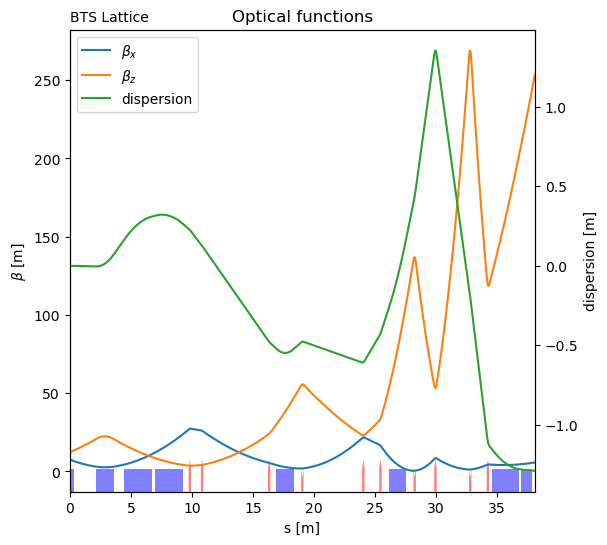

(<Axes: title={'left': 'BTS Lattice', 'center': 'Optical functions'}, xlabel='s [m]', ylabel='$\\beta$ [m]'>,
 <Axes: ylabel='dispersion [m]'>,
 <Axes: >)

In [20]:
bts_lattice.plot_beta(twiss_in=initial_twiss_parameters)

In [21]:
# Desired Twiss parameters at the end of the lattice
desired_twiss = {
    'beta': [15.0, 15.0],   # Target beta values at the end [beta_x, beta_y]
    'alpha': [0.0, 0.0],    # Target alpha values at the end [alpha_x, alpha_y]
    'dispersion': [0.0, 0.0]  # Target dispersion at the end [Dx, Dpx]
}

In [22]:
# Function to set quadrupole strengths
def set_quadrupole_strengths(strengths):
    q11.K, q12.K, q13.K, q21.K, q22.K, q23.K, q31.K, q32.K, q33.K = strengths

In [23]:
class TwissOptimizationProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(n_var=9, n_obj=6, n_constr=2, xl=-2.0, xu=2.0)  # Set appropriate bounds for quadrupole strengths

    def _evaluate(self, strengths, out, *args, **kwargs):
        # Set the quadrupole strengths
        set_quadrupole_strengths(strengths)

        # Perform linear optics analysis using linopt6
        linopt0, latopt, linopt = at.linopt6(bts_lattice, refpts=len(bts_lattice), twiss_in=initial_twiss_parameters)

        # Extract beta, alpha, and dispersion values at the end of the lattice
        beta_end = linopt['beta'][-1]       # [beta_x, beta_y] at the end of the lattice
        alpha_end = linopt['alpha'][-1]     # [alpha_x, alpha_y] at the end of the lattice
        dispersion_end = linopt['dispersion'][-1]  # [Dx, Dpx, Dy, Dpy] at the end of the lattice

        # Define the objectives
        out["F"] = [
            abs(beta_end[0] - desired_twiss['beta'][0]),     # Difference for beta_x
            abs(beta_end[1] - desired_twiss['beta'][1]),     # Difference for beta_y
            abs(alpha_end[0] - desired_twiss['alpha'][0]),   # Difference for alpha_x
            abs(alpha_end[1] - desired_twiss['alpha'][1]),   # Difference for alpha_y
            abs(dispersion_end[0] - desired_twiss['dispersion'][0]),   # Difference for dispersion_x (Dx)
            abs(dispersion_end[1] - desired_twiss['dispersion'][1])    # Difference for dispersion_x' (Dpx)
        ]

        # Define the constraints: both beta_x and beta_y should be less than 60
        out["G"] = [
            beta_end[0] - 60,   # beta_x must be < 60
            beta_end[1] - 60    # beta_y must be < 60
        ]

In [24]:
from pymoo.core.callback import Callback

class MyCallback(Callback):
    def __init__(self):
        super().__init__()

    def notify(self, algorithm):
        # Print the generation number and the minimum objective value in the population
        gen = algorithm.n_gen
        best_obj = algorithm.pop.get("F").min(axis=0)
        print(f"Generation: {gen}, Best Objective Values: {best_obj}")

# Set up the callback for displaying information during optimization
callback = MyCallback()

In [25]:
import time
t0 = time.time()

# Set up the NSGA-II algorithm with a seed for reproducibility
algorithm = NSGA2(pop_size=100, seed=1)

# Define the problem instance
problem = TwissOptimizationProblem()

# Set the termination criteria for the optimization
termination = get_termination("n_gen", 200)  # Terminate after 200 generations

# Perform the optimization using pymoo
result = minimize(problem, 
                  algorithm, 
                  termination, 
                  verbose=True, 
                  callback=callback
                 )

t1 = time.time()
print ((t1-t0), "seconds to optmize")

/home/cspark/Work/simulation_codes-working/miniforge3/envs/pyat-dev/lib/python3.11/site-packages/at/physics/linear.py:132: AtWarning: Unstable ring
  warnings.warn(AtWarning('Unstable ring'))


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |      3 |  0.000000E+00 |  9.277328E+04 |             - |             -
Generation: 1, Best Objective Values: [0.02525358 1.96941989 0.32237378 0.13890998 0.03747889 0.00803913]
     2 |      200 |      6 |  0.000000E+00 |  1.101023E+03 |  0.0141354306 |         ideal
Generation: 2, Best Objective Values: [0.02525358 1.96941989 0.27907649 0.13890998 0.01015965 0.01544743]
     3 |      300 |     17 |  0.000000E+00 |  1.937054E+02 |  0.1173138142 |         ideal
Generation: 3, Best Objective Values: [0.02525358 0.16022874 0.27907649 0.13890998 0.01015965 0.01544743]
     4 |      400 |     36 |  0.000000E+00 |  3.074736E+01 |  0.0094683193 |         ideal
Generation: 4, Best Objective Values: [0.02525358 0.16022874 0.09295263 0.13890998 0.01222416 0.02475844]
     5 |      500 |     64 |  0.000000E+00 |  0.3502414789 |  0.0461104892 |         ideal
Generation: 5, Best Objective 

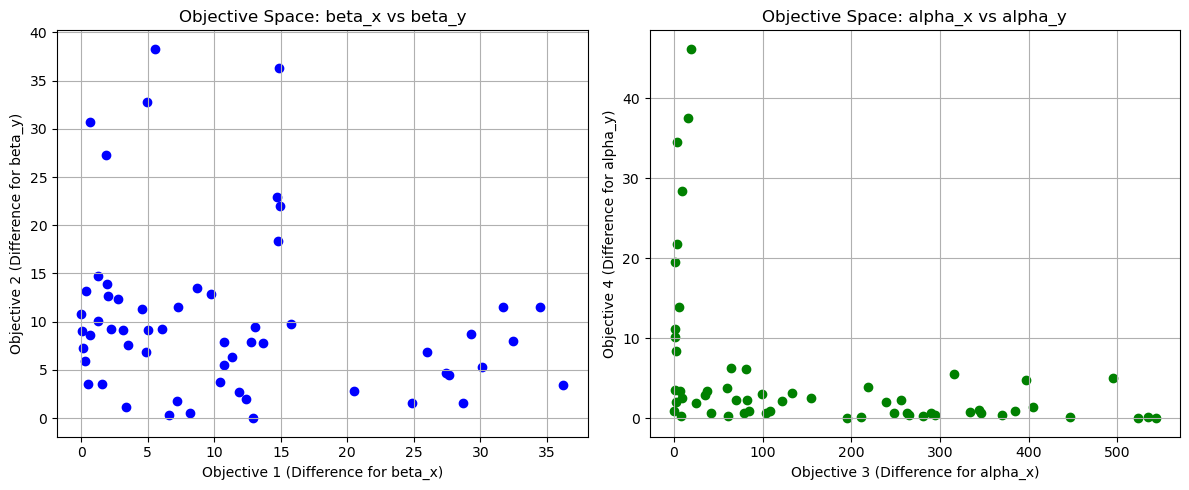

In [26]:
# Extract the Pareto front
F = result.F  # Objective values of the solutions in the Pareto front

# Remove outliers using the IQR method
def remove_outliers_iqr(data, factor=1.5):
    q1 = np.percentile(data, 25, axis=0)
    q3 = np.percentile(data, 75, axis=0)
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    
    # Filter data points that lie within the bounds for all objectives
    mask = np.all((data >= lower_bound) & (data <= upper_bound), axis=1)
    return data[mask]

# Apply the IQR filter to remove outliers
F_filtered = remove_outliers_iqr(F)

# Plot beta_x vs beta_y in objective space
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(F_filtered[:, 0], F_filtered[:, 1], c='blue', marker='o')
plt.xlabel('Objective 1 (Difference for beta_x)')
plt.ylabel('Objective 2 (Difference for beta_y)')
plt.title('Objective Space: beta_x vs beta_y')
plt.grid(True)

# Plot alpha_x vs alpha_y in objective space
plt.subplot(1, 2, 2)
plt.scatter(F_filtered[:, 2], F_filtered[:, 3], c='green', marker='o')
plt.xlabel('Objective 3 (Difference for alpha_x)')
plt.ylabel('Objective 4 (Difference for alpha_y)')
plt.title('Objective Space: alpha_x vs alpha_y')
plt.grid(True)

plt.tight_layout()

Original quadrupole strengths: (np.float64(0.738), np.float64(0.415), np.float64(0.415), np.float64(-0.9902), np.float64(1.288), np.float64(1.288), np.float64(-2.08), np.float64(4.13), np.float64(-2.24))
Optimized quadrupole strengths for most minimal objectives: [ 1.84879238  0.31741175 -1.56966948  1.8888027  -0.48837965 -1.89955115
 -0.20484612 -1.14300602 -1.98393448]
Objective values for the selected solution: [0.83155713 1.09084984 6.24185824 0.96714586 6.69193405 2.66462461]


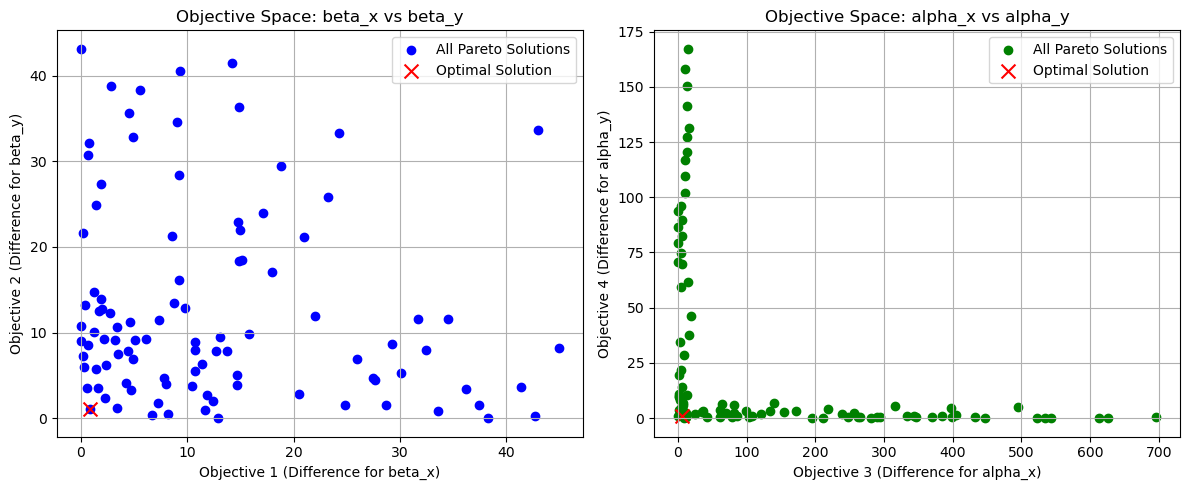

In [31]:
# Extract the Pareto front
F = result.F  # Objective values of the solutions in the Pareto front

# Calculate the sum of objective values for each solution
objective_sums = np.sum(F, axis=1)

# Find the index of the solution with the minimum sum of objectives
min_index = np.argmin(objective_sums)

# Extract the optimal solution with minimal objectives
optimal_solution = result.X[min_index]
optimal_objectives = F[min_index]

# Original Quad strengths
print("Original quadrupole strengths:", original_strengths)

# Print the optimized solution and its objective values
print("Optimized quadrupole strengths for most minimal objectives:", optimal_solution)
print("Objective values for the selected solution:", optimal_objectives)

# Apply the optimized strengths to the lattice
set_quadrupole_strengths(optimal_solution)

# Plot beta_x vs beta_y in objective space
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(F[:, 0], F[:, 1], c='blue', marker='o', label='All Pareto Solutions')
plt.scatter(optimal_objectives[0], optimal_objectives[1], c='red', marker='x', s=100, label='Optimal Solution')
plt.xlabel('Objective 1 (Difference for beta_x)')
plt.ylabel('Objective 2 (Difference for beta_y)')
plt.title('Objective Space: beta_x vs beta_y')
plt.grid(True)
plt.legend()

# Plot alpha_x vs alpha_y in objective space
plt.subplot(1, 2, 2)
plt.scatter(F[:, 2], F[:, 3], c='green', marker='o', label='All Pareto Solutions')
plt.scatter(optimal_objectives[2], optimal_objectives[3], c='red', marker='x', s=100, label='Optimal Solution')
plt.xlabel('Objective 3 (Difference for alpha_x)')
plt.ylabel('Objective 4 (Difference for alpha_y)')
plt.title('Objective Space: alpha_x vs alpha_y')
plt.grid(True)
plt.legend()

plt.tight_layout()

/home/cspark/Work/simulation_codes-working/miniforge3/envs/pyat-dev/lib/python3.11/site-packages/at/physics/linear.py:132: AtWarning: Unstable ring
  warnings.warn(AtWarning('Unstable ring'))


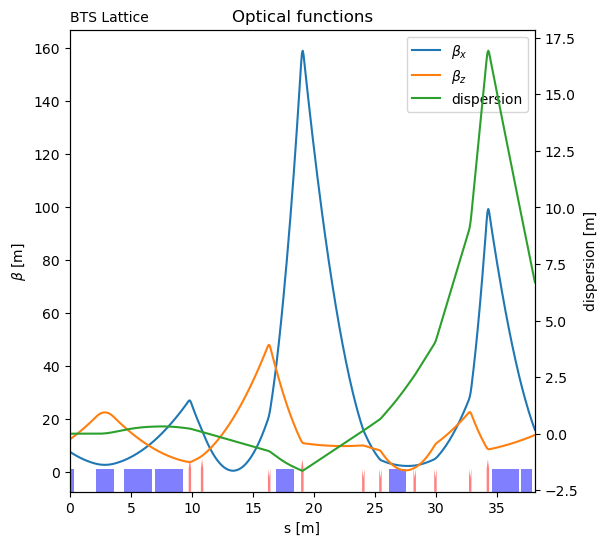

(<Axes: title={'left': 'BTS Lattice', 'center': 'Optical functions'}, xlabel='s [m]', ylabel='$\\beta$ [m]'>,
 <Axes: ylabel='dispersion [m]'>,
 <Axes: >)

In [35]:
bts_lattice.plot_beta(twiss_in=initial_twiss_parameters)